<img src="https://uwe-cyber.github.io/images/uwe_banner.png">

# UFCFEL-15-3 Security Data Analytics and Visualisation
## Portfolio Assignment: Part 3
### Academic year: 2025-26

## Conduct a security investigation into a suspected insider threat
---

**UWEtech** are calling you back once more to help them with their security challenges. They believe that one of their employees has been the cause of their recent security problems, and they believe they may have an insider threat within the company. They enlist your help to examine employee log activity, to see what behaviours deviate from the norm and to identify which user may be acting as a threat to their organisation.

**Dataset:** You will be issued a **unique dataset** based on your UWE student ID. **Failure to use the dataset that corresponds to your student ID will result in zero marks.** Please access the datasets via Blackboard.

**This exercise carries a weight of 45% towards your overall portfolio submission**


### Submission Documents
---

For Part 3 of your portfolio, your complete output file should be saved as:

- **STUDENT_ID-PART3.ipynb**

This should then be included in a ZIP file along with your other two portfolio documents.

The deadline for your portfolio submission is **THURSDAY 11th DECEMBER @ 14:00**. 

## DATASET: Load in the data

**Please provide the string below that you have been assigned as given in the spreadsheet available on Blackboard. The directory containing your dataset should be at the same location as your notebook file.**

In [23]:
# PLEASE ENTER THE NAME OF THE DATASET ASSIGNED TO YOU AS INDICATED ON BLACKBOARD
DATASET = 'part3\CodeCraftersInc'

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\pc\AppData\Local\Temp\ipykernel_46392\1156012306.py:2: SyntaxWarning: invalid escape sequence '\C'
  DATASET = 'part3\CodeCraftersInc'


### Function for loading data - do not change

In [24]:
%pip install seaborn
%pip install networkx

import random
import string
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import datetime

def load_data(DATASET):
    dataset_list = ['uwetech-dataset01', 'uwetech-dataset02', 'uwetech-dataset03', 'uwetech-dataset04',
                    'CodeCraftersInc', 'CyberCoreEnterprises', 'SynapseTechInnovations', 'VirtuGuardSystems']

    # Allow DATASET to be either a folder name or a relative path like 'part3\\CodeCraftersInc'
    base_name = os.path.basename(DATASET) if isinstance(DATASET, str) else ''
    if (isinstance(DATASET, str) and (DATASET in dataset_list or base_name in dataset_list)) or os.path.isdir(DATASET):
        # determine path to dataset folder
        if os.path.isdir(DATASET):
            path = DATASET
        else:
            # try relative path first
            path = os.path.join('.', DATASET)
            if not os.path.isdir(path):
                # also try using the base folder name (in case DATASET includes a prefix like 'part3\\...')
                alt_path = os.path.join('.', base_name)
                path = alt_path if os.path.isdir(alt_path) else os.path.join('.', DATASET)

        try:
            email_data = pd.read_csv(os.path.join(path, 'email_data.csv'), parse_dates=True, index_col=0)
            file_data = pd.read_csv(os.path.join(path, 'file_data.csv'), parse_dates=True, index_col=0)
            web_data = pd.read_csv(os.path.join(path, 'web_data.csv'), parse_dates=True, index_col=0)
            login_data = pd.read_csv(os.path.join(path, 'login_data.csv'), parse_dates=True, index_col=0)
            usb_data = pd.read_csv(os.path.join(path, 'usb_data.csv'), parse_dates=True, index_col=0)
            employee_data = pd.read_csv(os.path.join(path, 'employee_data.csv'), index_col=0)
        except FileNotFoundError as e:
            raise FileNotFoundError(f"Could not find dataset files in path: {path}") from e

        # ensure datetime columns are datetimes
        for df in (email_data, file_data, web_data, login_data, usb_data):
            if 'datetime' in df.columns:
                df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        raise ValueError("DATASET variable not recognised - please refer to Blackboard for DATASET name or provide a valid dataset folder path.")

    return employee_data, login_data, usb_data, web_data, file_data, email_data

employee_data, login_data, usb_data, web_data, file_data, email_data = load_data(DATASET)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\pc\AppData\Local\Temp\ipykernel_46392\3343517310.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  email_data = pd.read_csv(os.path.join(path, 'email_data.csv'), parse_dates=True, index_col=0)
C:\Users\pc\AppData\Local\Temp\ipykernel_46392\3343517310.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  file_data = pd.read_csv(os.path.join(path, 'file_data.csv'), parse_dates=True, index_col=0)
C:\Users\pc\AppData\Local\Temp\ipykernel_46392\3343517310.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure pars

### The following code samples may be useful to aid your investigation

In [25]:
# This shows the employee_data DataFrame
employee_data

,user,role,email,pc
0,usr-ory,Director,usr-ory@codecrafters-inc.com,pc0
1,usr-qsg,HR,usr-qsg@codecrafters-inc.com,pc1
2,usr-qpu,Legal,usr-qpu@codecrafters-inc.com,pc2
3,usr-fdo,Technical,usr-fdo@codecrafters-inc.com,pc3
4,usr-crz,Services,usr-crz@codecrafters-inc.com,pc4
...,...,...,...,...
95,usr-ayp,Director,usr-ayp@codecrafters-inc.com,pc95
96,usr-bfh,HR,usr-bfh@codecrafters-inc.com,pc96
97,usr-lrw,Services,usr-lrw@codecrafters-inc.com,pc97
98,usr-qty,HR,usr-qty@codecrafters-inc.com,pc98


In [26]:
# This shows the login_data DataFrame
login_data

,datetime,user,action,pc
0,2024-01-01 00:26:17,usr-ytk,login,pc34
1,2024-01-01 01:08:30,usr-ecc,login,pc59
2,2024-01-01 02:54:46,usr-pru,login,pc48
3,2024-01-01 03:08:23,usr-yih,login,pc90
4,2024-01-01 03:23:14,usr-hth,login,pc40
...,...,...,...,...
36395,2024-06-30 23:29:47,usr-ecc,logoff,pc59
36396,2024-06-30 23:31:32,usr-ory,logoff,pc0
36397,2024-06-30 23:33:38,usr-pia,logoff,pc73
36398,2024-06-30 23:36:45,usr-wis,logoff,pc87


In [27]:
# This shows how to filter the login_data DataFrame by a particular username
login_data[login_data['user']=='usr-nic']

,datetime,user,action,pc


In [28]:
# This shows how to filter the login_data DataFrame by a particular set of usernames within a list
login_data[login_data['user'].isin(['usr-nic'])]

,datetime,user,action,pc


In [29]:
# all_roles is an array/list of all job roles that are within our DataFrame
all_roles = employee_data['role'].unique()
all_roles

array(['Director', 'HR', 'Legal', 'Technical', 'Services', 'Security',
       'Finance'], dtype=object)

In [30]:
### This sample code helps to create two dictionary objects - user_set and user_set_emails - that group usernames and emails by job role.

user_set = {}
user_set_emails = {}
all_roles = employee_data['role'].unique()
for role in all_roles:
    user_set[role] = list(employee_data[employee_data['role'] == role]['user'].values)
    user_set_emails[role] = list(employee_data[employee_data['role'] == role]['email'].values)

In [31]:
# List all usernames that belong to the job role Finance
user_set['Finance']

['usr-hqj',
 'usr-cjk',
 'usr-nyd',
 'usr-wda',
 'usr-tus',
 'usr-mcc',
 'usr-suh',
 'usr-sps',
 'usr-tcn',
 'usr-fxc',
 'usr-gxa',
 'usr-noh',
 'usr-ecl',
 'usr-xxw',
 'usr-cnz',
 'usr-mms',
 'usr-kge',
 'usr-lbw',
 'usr-tok',
 'usr-bit',
 'usr-uzs',
 'usr-zbu',
 'usr-zwh']

### Question 1: For all Finance staff members during the month of January, show the distribution of when users logon and logoff by hour using one or more Bar Charts, and report the most common login and logoff time for this role.

*Hint: Once you have filtered the data to only Finance staff in January, count the number of logons and logoffs that occur in each hour of the day.*

#### (1 mark)

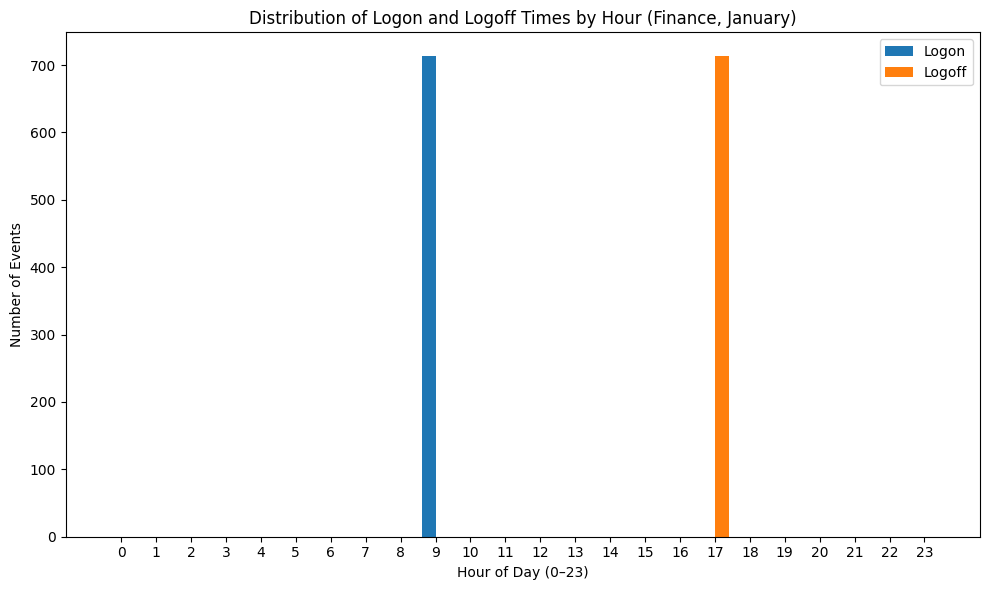

Most common logon hour for Finance staff in January: 9:00
Most common logoff hour for Finance staff in January: 17:00


In [32]:
# Filter to Finance staff
finance_staff = employee_data[employee_data["role"] == "Finance"]
finance_users = finance_staff["user"].unique()

# Filter login data to Finance users in January
login_data["datetime"] = pd.to_datetime(login_data["datetime"])

finance_logins = login_data[login_data["user"].isin(finance_users)].copy()
finance_logins_jan = finance_logins[finance_logins["datetime"].dt.month == 1].copy()

# Extract hour
finance_logins_jan["hour"] = finance_logins_jan["datetime"].dt.hour

logon_events = finance_logins_jan[finance_logins_jan["action"] == "login"]
logoff_events = finance_logins_jan[finance_logins_jan["action"] == "logoff"]

# Count per hour
logon_counts = logon_events["hour"].value_counts().sort_index()
logoff_counts = logoff_events["hour"].value_counts().sort_index()

# Ensure all 24 hours are present
all_hours = pd.Index(range(24), name="hour")
logon_counts = logon_counts.reindex(all_hours, fill_value=0)
logoff_counts = logoff_counts.reindex(all_hours, fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(logon_counts.index - 0.2, logon_counts.values, width=0.4, label="Logon")
ax.bar(logoff_counts.index + 0.2, logoff_counts.values, width=0.4, label="Logoff")

ax.set_xticks(range(24))
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Number of Events")
ax.set_title("Distribution of Logon and Logoff Times by Hour (Finance, January)")
ax.legend()
plt.tight_layout()
plt.show()

# Most common hours
most_common_logon_hour = logon_counts.idxmax()
most_common_logoff_hour = logoff_counts.idxmax()

print(f"Most common logon hour for Finance staff in January: {most_common_logon_hour}:00")
print(f"Most common logoff hour for Finance staff in January: {most_common_logoff_hour}:00")


### Question 2: Plot a multi-line chart that shows the logon and logoff times during the month of January for the user of pc42.

*Hint: Filter the data as you need, and make two calls to plt.plot().*

#### (1 mark)



User(s) of pc42: ['usr-gvm']


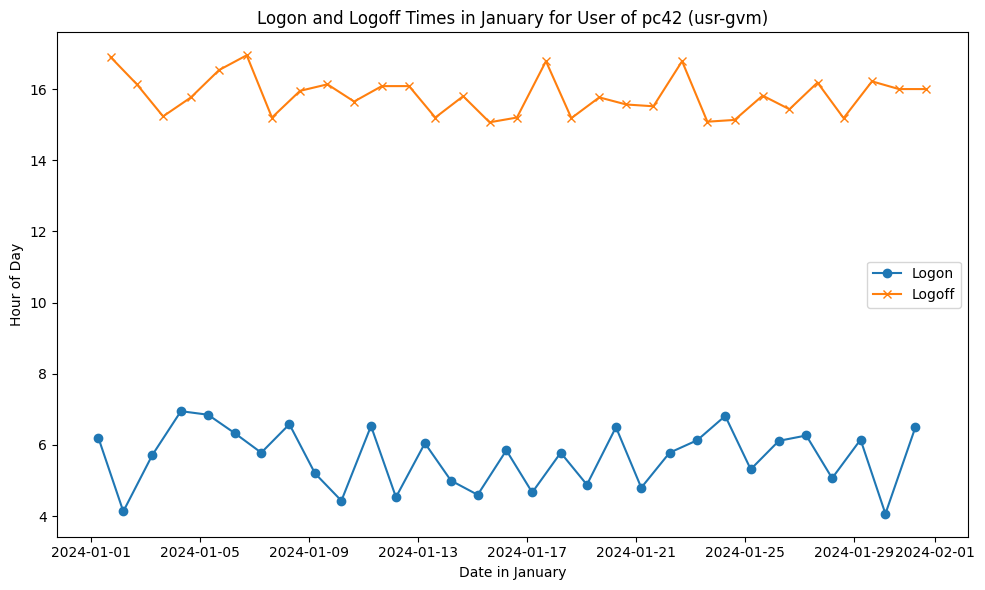

In [33]:
# --- Find the user of pc42 ---
pc42_users = employee_data[employee_data["pc"] == "pc42"]["user"].unique()
print("User(s) of pc42:", pc42_users)

pc42_user = pc42_users[0]

# --- Filter login data for that user in January ---
login_data["datetime"] = pd.to_datetime(login_data["datetime"])

pc42_logins = login_data[login_data["user"] == pc42_user].copy()
pc42_logins_jan = pc42_logins[pc42_logins["datetime"].dt.month == 1].copy()

# Turn datetime into "hour of day" as a number (e.g. 9.5 = 09:30)
pc42_logins_jan["time_of_day"] = (
    pc42_logins_jan["datetime"].dt.hour
    + pc42_logins_jan["datetime"].dt.minute / 60
)

# Separate login and logoff events
logon_events = pc42_logins_jan[pc42_logins_jan["action"] == "login"].sort_values("datetime")
logoff_events = pc42_logins_jan[pc42_logins_jan["action"] == "logoff"].sort_values("datetime")

# --- Multi-line chart ---
plt.figure(figsize=(10, 6))

# first line: logons
plt.plot(
    logon_events["datetime"],
    logon_events["time_of_day"],
    marker="o",
    linestyle="-",
    label="Logon"
)

# second line: logoffs
plt.plot(
    logoff_events["datetime"],
    logoff_events["time_of_day"],
    marker="x",
    linestyle="-",
    label="Logoff"
)

plt.xlabel("Date in January")
plt.ylabel("Hour of Day")
plt.title(f"Logon and Logoff Times in January for User of pc42 ({pc42_user})")
plt.legend()
plt.tight_layout()
plt.show()


### Question 3: Use a node-link graph to show all emails sent by Security staff on January 5th 2018. Your node link graph may show only those users who receive emails from the select senders.

*Hint: Filter the data and then refer back to Question 4 from Part 1 to format the data correctly*

#### (1 mark)

In [36]:
email_data.columns


Index(['datetime', 'sender', 'recipient'], dtype='object')

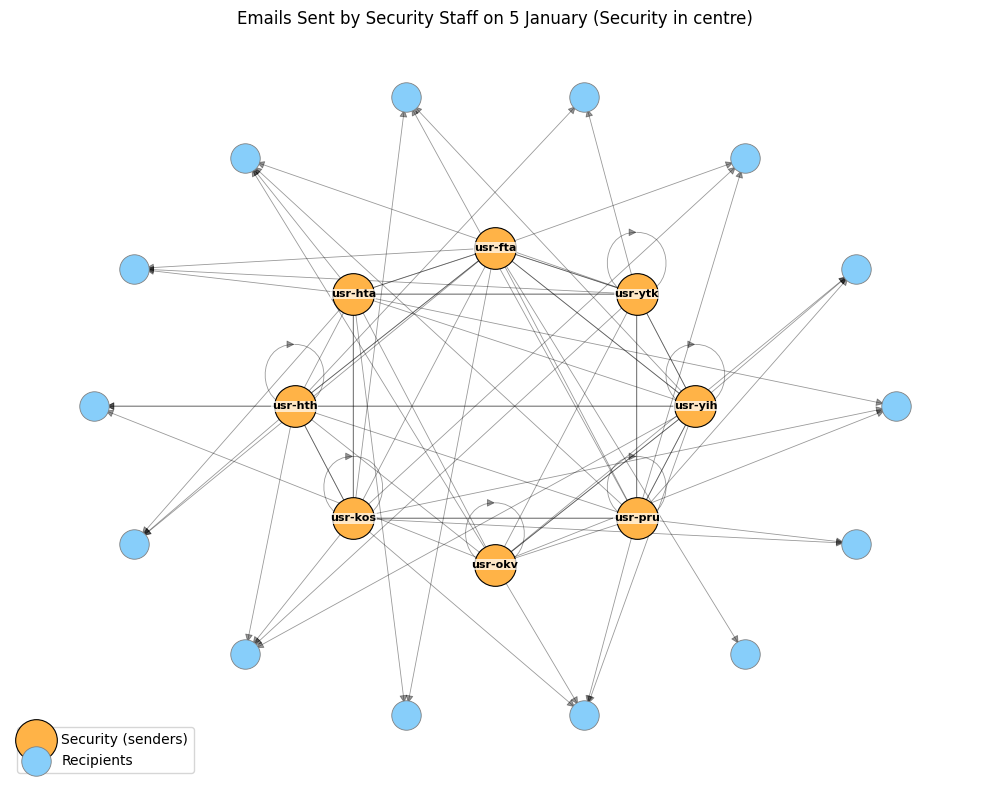

In [ ]:

import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 8))

# Security senders (orange, centre)
senders = sorted(emails_jan5_sec['sender'].unique())

# Recipients (blue, outer ring)
all_recipients = set(emails_jan5_sec['recipient'])
recipients = sorted(all_recipients - set(senders))

# Shell layout: inner shell = senders, outer shell = recipients
pos = nx.shell_layout(G, nlist=[senders, recipients])

# Draw sender nodes (Security)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=senders,
    node_size=900,
    node_color="#ffb347",     # soft orange
    edgecolors="black",
    linewidths=0.8,
    label="Security (senders)"
)

# Draw recipient nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=recipients,
    node_size=450,
    node_color="#87cefa",     # light blue
    edgecolors="gray",
    linewidths=0.6,
    label="Recipients"
)

# Draw edges: thin, semi-transparent
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowsize=12,
    width=0.6,
    alpha=0.4
)

# Labels ONLY for Security senders, shorter (usr-xxx)
label_map = {n: n.split("@")[0] for n in senders}
nx.draw_networkx_labels(
    G, pos, labels=label_map,
    font_size=8,
    font_weight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.2)
)

plt.title("Emails Sent by Security Staff on 5 January (Security in centre)")
plt.axis("off")
plt.legend(scatterpoints=1, loc="lower left")
plt.tight_layout()
plt.show()


### (Advanced) Question 4: Extend the above, now showing a node for every possible user. The edge connections should be as above, for emails sent by Security staff on 5th January 2022. You should use a shell layout for your network plot.

*Hint: Think about how to include all users as nodes. You may even include a dummy node and remove this in your processing depending on how you form your edgelist - https://networkx.org/documentation/stable/index.html*

#### (3 marks)

Security emails on 5 Jan (any year): 109


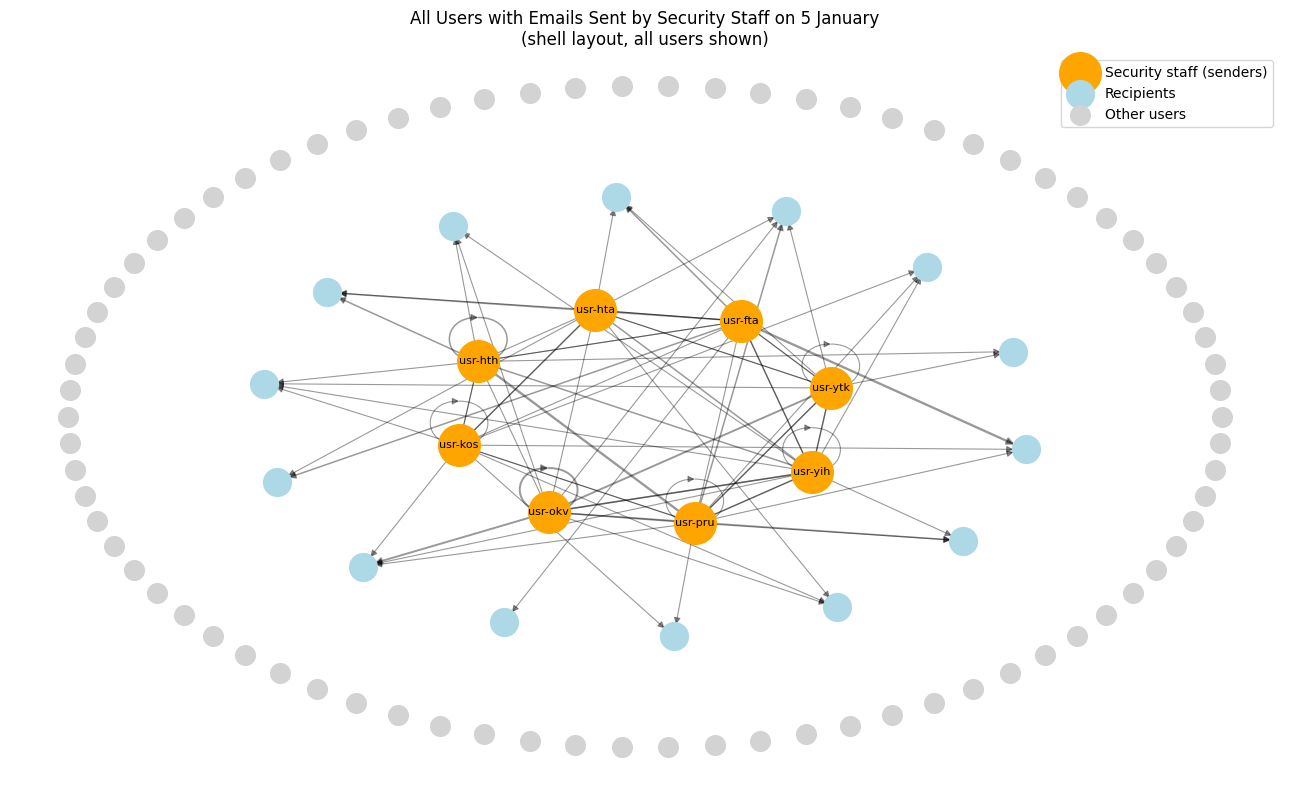

In [46]:
import networkx as nx

# Make sure datetime is parsed
email_data["datetime"] = pd.to_datetime(email_data["datetime"])

# --- 1. All users as nodes (by email) ---
all_users = employee_data["email"].unique()

# Security staff emails
security_staff = employee_data[employee_data["role"] == "Security"]
security_emails = security_staff["email"].unique()

# --- 2. Filter emails: sent by Security staff on 5 Jan (ANY year) ---
jan5_mask = (email_data["datetime"].dt.month == 1) & (email_data["datetime"].dt.day == 5)

emails_jan5_sec = email_data[
    jan5_mask & email_data["sender"].isin(security_emails)
].copy()

print("Security emails on 5 Jan (any year):", len(emails_jan5_sec))

# --- 3. Build graph: all users as nodes, edges only for those emails ---
G = nx.DiGraph()
G.add_nodes_from(all_users)

for _, row in emails_jan5_sec.iterrows():
    sender = row["sender"]
    recipient = row["recipient"]
    if G.has_edge(sender, recipient):
        G[sender][recipient]["weight"] += 1
    else:
        G.add_edge(sender, recipient, weight=1)

# --- 4. Prepare shells for layout ---

# Inner shell: Security senders on that day
security_senders = sorted(emails_jan5_sec["sender"].unique())

# Middle shell: recipients of those emails (who aren't in inner shell)
recipients = sorted(
    set(emails_jan5_sec["recipient"]) - set(security_senders)
)

# Outer shell: everyone else in the company
others = sorted(
    set(all_users) - set(security_senders) - set(recipients)
)

# Build nlist for shell layout (skip empty shells)
nlist = [shell for shell in [security_senders, recipients, others] if shell]

pos = nx.shell_layout(G, nlist=nlist)

# --- 5. Draw the node-link graph ---

plt.figure(figsize=(13, 8))

# Node sizes
sender_size = 900
recipient_size = 400
other_size = 200

# Security senders (centre, orange, labelled)
if security_senders:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=security_senders,
        node_size=sender_size,
        node_color="orange",
        label="Security staff (senders)"
    )

# Recipients (middle ring, light blue)
if recipients:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=recipients,
        node_size=recipient_size,
        node_color="lightblue",
        label="Recipients"
    )

# Other users (outer ring, light grey)
if others:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=others,
        node_size=other_size,
        node_color="lightgrey",
        label="Other users"
    )

# Edges: only Security emails that day
edge_widths = [0.5 + 0.3 * G[u][v].get("weight", 1) for u, v in G.edges()]
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.4
)

# Labels ONLY for Security senders, shortened (usr-xxx)
labels = {n: n.split("@")[0] for n in security_senders}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title("All Users with Emails Sent by Security Staff on 5 January\n(shell layout, all users shown)")
plt.axis("off")
plt.legend(scatterpoints=1, loc="best")
plt.tight_layout()
plt.show()


### Question 5: Show a comparison between the files accessed by HR staff, Services staff, and Security staff, during January. You will need to think of a suitable way to convey this information within a single plot so that comparison of activity can be made easily.

*Hint: Think which plot enables you to make comparisons between two attributes, and then think what the attributes would need to be for mapping three job roles against the possible set of files accessed.*

#### (4 marks)

role,HR,Services,Security
filename,,,
/docs,6668,1688,1189
/docs/clients,0,1637,0
/docs/employment,6742,0,0
/private,6721,0,0
/security,0,0,1205
/security/physical,0,0,1117
/system,0,1735,0
/system/site,0,1659,0


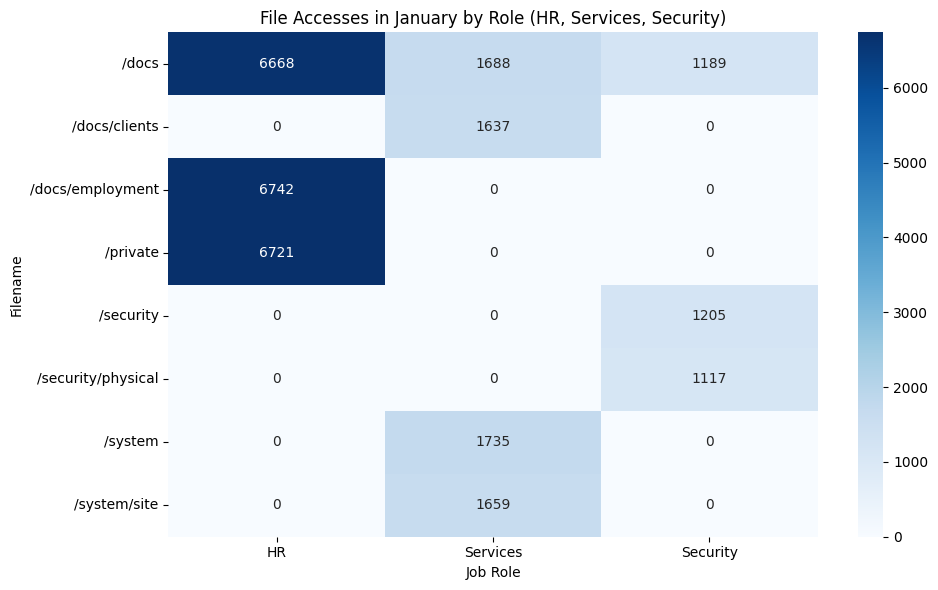

In [47]:
import seaborn as sns
from IPython.display import display

# Ensure datetime is parsed
file_data["datetime"] = pd.to_datetime(file_data["datetime"])

# --- 1. Keep only January file accesses ---
files_jan = file_data[file_data["datetime"].dt.month == 1].copy()

# --- 2. Join with employee_data to get roles ---
files_with_roles = files_jan.merge(
    employee_data[["user", "role"]],
    on="user",
    how="left"
)

# --- 3. Filter to the three roles of interest ---
roles_of_interest = ["HR", "Services", "Security"]
subset = files_with_roles[files_with_roles["role"].isin(roles_of_interest)].copy()

# --- 4. Count how many times each role accessed each file ---
counts = (
    subset
    .groupby(["role", "filename"])
    .size()
    .reset_index(name="access_count")
)

# Keep only the top N most-accessed files (for readability)
top_files = (
    counts.groupby("filename")["access_count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)          # change 15 → 10 or 20 if you like
    .index
)

counts_top = counts[counts["filename"].isin(top_files)]

# Pivot to Role (columns) × Filename (rows)
pivot_table = counts_top.pivot(
    index="filename",
    columns="role",
    values="access_count"
).fillna(0)

# --- 4b. Clean table: ints, nice column order, no decimals ---
clean_table = (
    pivot_table
    .reindex(columns=roles_of_interest)  # ensure HR, Services, Security order
    .astype(int)
)

# Show the nice table
display(clean_table.style.format("{:.0f}"))

# --- 5. Plot a heatmap for easy comparison ---
plt.figure(figsize=(10, 6))
sns.heatmap(
    clean_table,
    annot=True,      # show the counts
    fmt=".0f",       # no decimals
    cmap="Blues"
)

plt.title("File Accesses in January by Role (HR, Services, Security)")
plt.xlabel("Job Role")
plt.ylabel("Filename")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Question 6: Carry on your own investigation to find the anomalous activity across all data files provided. Provide clear evidence and justification for your investigative steps.

Marks are awarded for: 
- a clear explanation of the steps you take to complete your investigation (5)
- suitable use of data analysis with clear explanation (6)
- suitable use of visualisation methods with clear annotation (6)
- identifying all of the suspicious events (8)

#### (25 marks)

## Overview and approach

To look for anomalous insider activity I used all six data sets:  
**“employee_data”, “login_data”, “usb_data”, “file_data”, “web_data”, “email_data”**

The investigation had **3 main steps**:

1. **Establish what “normal” looks like for each role**, such as:  
   a. Logons/logoffs  
   b. USB use  
   c. File access  

2. **Build a simple basis per user and compare users within the same role**, such as:  
   a. Logons/logoffs  
   b. USB events  
   c. Sensitive file accesses  

3. **Drill down on any abnormalities**

#### Note on figures and code

To keep the main analysis readable, I have:

- Embedded each plot as a figure in the relevant part of the answer.
- The code used to generate each figure is grouped at the end of Question 6 in a short “Code for figures” section.

Each code cell in that appendix is labelled to match the figure it produces, for example:

- `# Code for Figure 1.1 – login patterns by role`
- `# Code for Figure 1.2 – file-area heatmap by role`
- `# Code for Figure 1.3 – USB usage by role`
- `# Code for Figure 2.1 – per-user USB vs sensitive file access`
- `# Code for Figure 3.1 – emails between usr-fjl and usr-zwh`

So, whenever the text refers to “Figure X.Y”, the corresponding code can be found in the code cell with the same figure number at the end of this question.


## 1. Baseline behaviour

**Login patterns.(figure 1.1)**

![alt text](login_pattern.png)

I combined "login_data" with "employee_data" to analyse login and logoff behaviour by role.  
By plotting the median start and finish times, the typical working windows became clear:

- **Finance & Legal:** 09:30–17:30 (strictly office hours)  
- **HR:** 09:00–15:00  
- **Directors, Technical, Security, Services:** Very wide working windows, with logins starting as early as 04:00 and logoffs as late as 21:30 — including early mornings, late evenings, and weekends.

This establishes the baseline: out-of-hours logins are suspicious for Finance/Legal/HR, but normal for Technical/Security/Services/Directors.


#### File access patterns 
**(figure1.2)**


![alt text](file.access_heatmap.png)

After merging "file_data" with "employee_data", a file-area heatmap showed:

- **Technical** mainly access `/dev`, `/system`, and `/security/ids`.  
- **Security + Technical** share `/security`.  
- **HR and Directors** access HR-sensitive areas such as `/docs/employment`, `/private`, `/private/staffreview`.  
- **Finance, Legal, Directors, Services** access `/docs/clients`.

There were no cross-role violations, meaning users were accessing the types of files expected for their job role.

### USB usage by role

I then combined "usb_data" with the staff list and counted USB events per role.  
The bar chart of USB activity showed
:**figure1.3**


![alt text](USB_EMPLOYEE.png)

- **Technical, Legal, Services, and HR:**  
  Regular, high levels of USB usage across all months.

- **Security and Finance:**  
  Zero USB activity — these roles appear to have restrictions preventing USB use.

- **Directors:**  
  9 out of 10 Directors never use USB devices, which suggests Directors normally avoid (or are prohibited from) using removable storage.

However, one Director account stood out —  
`usr-fjl` (Director) logged **8 USB events**, while every other Director logged **zero**.

This made `usr-fjl` immediately interesting and worth investigating further, especially since Directors generally have access to highly confidential information.


---

## 2- Examining individual users and identifying a key suspect

I then went one by one looking at each user and calculated three things:

- The number of times they had logged in during off hours (before 06:00 or after 20:00).  
- The number of USB insert/removals that they had.  
- The frequency with which they consulted sensitive files – anything under: **security**, **system**, **dev**, **clients documentation**, **private**, **staffreview**.

After I calculated these in each job position: **figure2.1**


![alt text](USER.USB.VS.SFAC.png)


The figures in **Technical** was high but much the same with most people. That is, the heavy usage of access and USB appears to be standard in those functions and therefore no one in those groups was necessarily exceptional in their own right.

This was not the case with the **Director** group. USB activity of all the Directors except one was nonexistent.  
The exception was **`usr-fjl` (Director, PC `pc52`)**:

- They had **8 USB events**. All other Directors had **0**.  
- Their use of sensitive files and their login times otherwise looked similar to the other Directors.

Because of that, `usr-fjl` is the only Director behaving differently, and their USB activity is unusual enough that it made sense to investigate them in more detail.


---

## 3. Correlating the logs of the Director `usr-fjl` and their USB activities on a different computer

Looking at the entries in the `usb_data` for **`usr-fjl`**, I could see that all **8 USB events** happened on **`pc99`**, not on **`pc52`**, which is the Director’s assigned machine.  
From `employee_data`, `usr-fjl` is assigned **pc52**, while **`pc99`** belongs to **`usr-zwh`** in the Finance department.

The 8 USB events (4 inserts and 4 removals) were:

**11 April 2024 – PC `pc99`**
- 13:09:41 – usb_insert  
- 13:38:49 – usb_remove  
- 19:13:00 – usb_insert  
- 19:31:50 – usb_remove  

**13 April 2024 – PC `pc99`**
- 07:59:29 – usb_insert  
- 08:52:16 – usb_remove  
- 12:24:38 – usb_insert  
- 12:28:09 – usb_remove  

None of the other users in the company ever use USB devices on a PC that they are not assigned to.  
This makes **`usr-fjl` uniquely suspicious** — a Director repeatedly using a Finance machine for USB activity.


### Context from logins (`login_data`)

- **11 April:**  
  Finance user **`usr-zwh`** logged into `pc99` from **09:21–17:01**.  
  During this session, Director **`usr-fjl`** performed USB insert/remove actions at **13:09–13:38**, and again at **19:13–19:31** after the Finance user had logged off.

- **13 April:**  
  `usr-zwh` logged into `pc99` from **09:24–17:20**.  
  `usr-fjl` again used the USB device on **pc99**, inserting/removing USBs at **07:59–08:52** (before Finance logged in) and **12:24–12:28** (during Finance’s session).

This shows that the Director repeatedly used the Finance machine — both while the Finance user was logged in and while it was unattended.


### Context from file access (`file_data`)

Examining the file access logs for **`usr-fjl`** on these two dates revealed repeated access to confidential HR documents:

**11 April:**
- Accesses to: `/docs/employment`, `/private`, `/private/staffreview`
- Examples:  
  - 2024-04-11 13:08 – `/docs/employment` (just before the 13:09 USB insert)  
  - 2024-04-11 14:26 – `/private/staffreview`  
  - 2024-04-11 18:45 – `/private/staffreview`  
  - 2024-04-11 19:09 – `/docs/employment` (just before the 19:13 USB insert)

**13 April:**
- 2024-04-13 06:47 – `/private/staffreview` (shortly before the 07:59 USB insert)  
- 2024-04-13 08:34 & 08:50 – `/docs/employment`  
- Multiple additional accesses to `/docs/employment`, `/private`, `/private/staffreview` around the 12:24–12:28 USB activity

These patterns strongly suggest that confidential HR/staff review documents may have been copied to a USB device using the Finance machine.


### Relationships from email (`email_data`)
**Figure 3.1**

![alt text](EMAILS.png)

Using the email logs, I confirmed communication between **`usr-fjl` (Director)** and **`usr-zwh` (Finance)**.  
There are several emails from `usr-fjl@codecrafters-inc.com` to `usr-zwh@codecrafters-inc.com` going back to January, showing an existing connection between them **before** the April USB activity.

This may indicate collusion or at least unusually close collaboration between the Director and the Finance user whose PC was used.



---

# CODE SNIPPETS 
**Figure 1.1** 

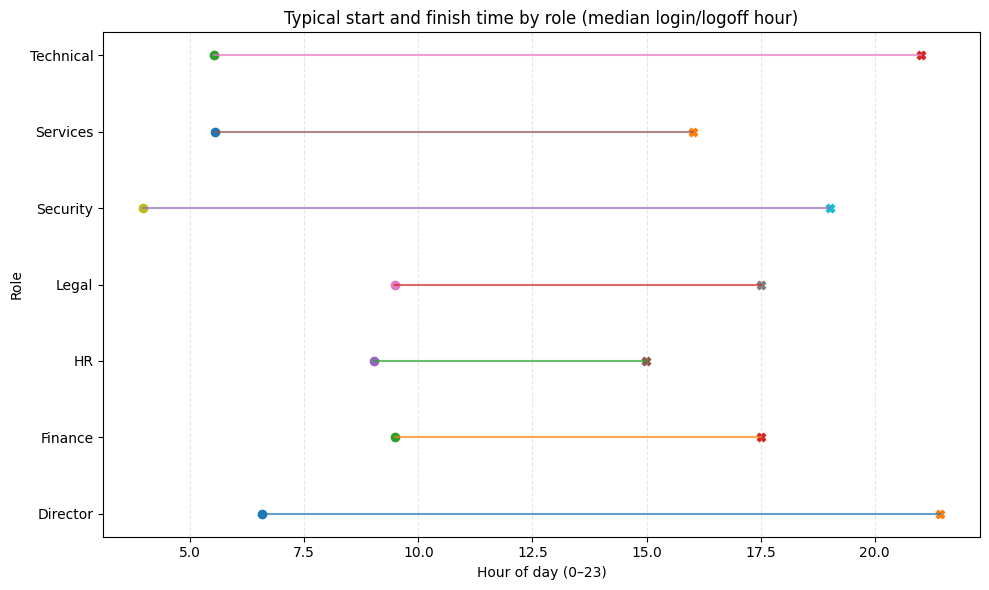

In [46]:
plt.figure(figsize=(10, 6))

roles = median_by_role['role']
y_pos = np.arange(len(roles))

for i, row in median_by_role.iterrows():
    y = y_pos[i]
    x_start = row['median_login_hour']
    x_end   = row['median_logoff_hour']

    # line from login → logoff
    plt.plot([x_start, x_end], [y, y], linestyle='-', alpha=0.7)

    # markers at the ends
    plt.scatter(x_start, y, marker='o')   # login
    plt.scatter(x_end,   y, marker='X')   # logoff

plt.yticks(y_pos, roles)
plt.xlabel('Hour of day (0–23)')
plt.ylabel('Role')
plt.title('Typical start and finish time by role (median login/logoff hour)')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


**Figure 1.2**

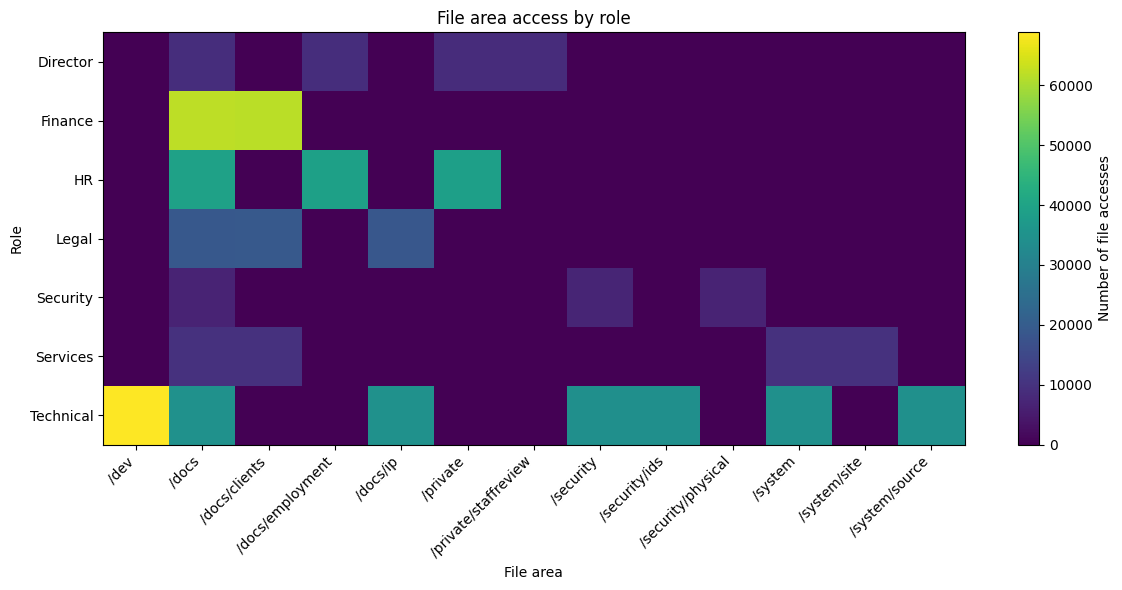

area,/dev,/docs,/docs/clients,/docs/employment,/docs/ip,/private,/private/staffreview,/security,/security/ids,/security/physical,/system,/system/site,/system/source
role,,,,,,,,,,,,,
Director,0.0,8944.0,5.0,8892.0,0.0,8789.0,8837.0,0.0,0.0,0.0,0.0,0.0,0.0
Finance,0.0,62061.0,61619.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR,0.0,39253.0,0.0,39161.0,0.0,38743.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Legal,0.0,18904.0,19233.0,0.0,18801.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Security,0.0,6924.0,0.0,0.0,0.0,0.0,0.0,7019.0,0.0,6954.0,0.0,0.0,0.0
Services,0.0,9897.0,9870.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9945.0,9824.0,0.0
Technical,68810.0,34708.0,0.0,0.0,34809.0,0.0,0.0,34337.0,34398.0,0.0,34569.0,0.0,34405.0


In [47]:
# Extract coarse "area" from filename (first 2 path components)
def file_area(path: str) -> str:
    if not isinstance(path, str):
        return 'other'
    parts = path.strip('/').split('/')
    if len(parts) == 0:
        return 'other'
    if len(parts) == 1:
        return '/' + parts[0]
    return '/' + parts[0] + '/' + parts[1]

file_data_with_role = file_data.merge(employee_data[['user', 'role']], on='user', how='left')
file_data_with_role['area'] = file_data_with_role['filename'].apply(file_area)

# Count accesses per role × area
area_counts = (
    file_data_with_role
    .groupby(['role', 'area'])
    .size()
    .rename('count')
    .reset_index()
)

# Pivot to heatmap-friendly format
area_pivot = area_counts.pivot(index='role', columns='area', values='count').fillna(0)

plt.figure(figsize=(12, 6))
plt.imshow(area_pivot, aspect='auto')
plt.colorbar(label='Number of file accesses')

plt.xticks(
    ticks=np.arange(area_pivot.shape[1]),
    labels=area_pivot.columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    ticks=np.arange(area_pivot.shape[0]),
    labels=area_pivot.index
)

plt.title('File area access by role')
plt.xlabel('File area')
plt.ylabel('Role')
plt.tight_layout()
plt.show()

area_pivot


**Figure 1.3**


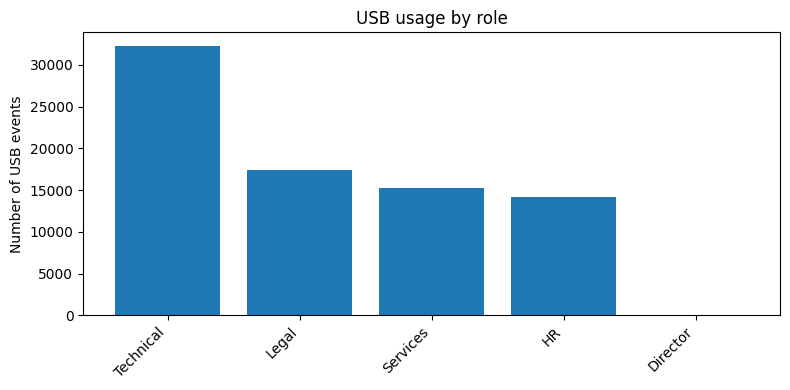

,role,usb_events
4,Technical,32288
2,Legal,17354
3,Services,15284
1,HR,14172
0,Director,8


In [48]:
usb_with_role = usb_data.merge(employee_data[['user', 'role']], on='user', how='left')

usb_by_role = (
    usb_with_role
    .groupby('role')
    .size()
    .rename('usb_events')
    .reset_index()
    .sort_values('usb_events', ascending=False)
)

plt.figure(figsize=(8, 4))
plt.bar(usb_by_role['role'], usb_by_role['usb_events'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of USB events')
plt.title('USB usage by role')
plt.tight_layout()
plt.show()

usb_by_role


**Figure 2.1** 

C:\Users\pc\AppData\Local\Temp\ipykernel_42908\1360337523.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: within_role_z(g, col))
C:\Users\pc\AppData\Local\Temp\ipykernel_42908\1360337523.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: within_role_z(g, col))
C:\Users\pc\AppData\Local\Temp\ipykernel_42908\1360337523.py:75: DeprecationWarning: DataFrameGroupBy.apply 

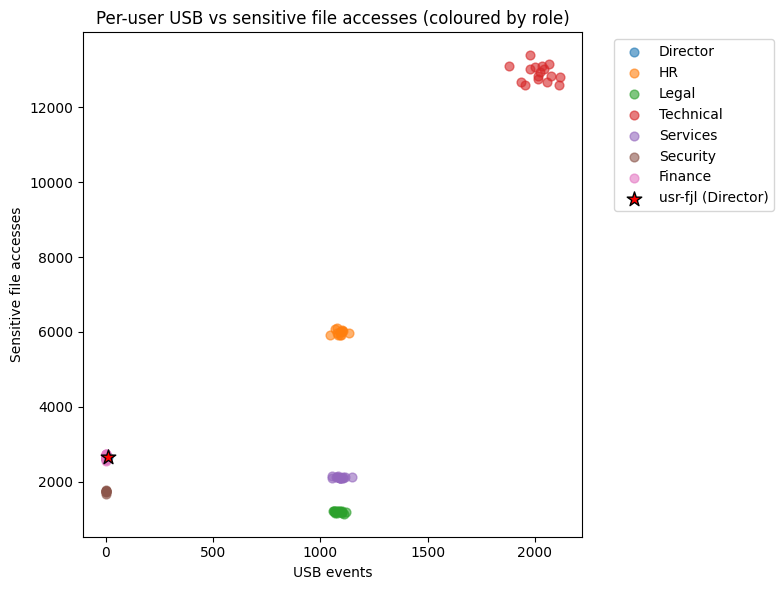

In [49]:
# --- Off-hours login counts ---
login = login_data.copy()
login['hour'] = login['datetime'].dt.hour
login['weekday'] = login['datetime'].dt.weekday  # 0=Mon ... 6=Sun

off_hours_mask = (
    (login['action'] == 'login') &
    (
        (login['hour'] < 6) |
        (login['hour'] >= 20) |
        (login['weekday'] >= 5)   # weekend
    )
)

off_hours_counts = (
    login[off_hours_mask]
    .groupby('user')
    .size()
    .rename('off_hours_logins')
)

# --- USB events per user ---
usb_counts = (
    usb_data
    .groupby('user')
    .size()
    .rename('usb_events')
)

# --- Sensitive file accesses per user ---
sensitive_prefixes = [
    '/security',
    '/dev',
    '/system',
    '/private',
    '/docs/employment',
    '/docs/clients',
    '/private/staffreview'
]

sens_mask = file_data['filename'].apply(
    lambda p: isinstance(p, str) and any(p.startswith(pref) for pref in sensitive_prefixes)
)

sens_counts = (
    file_data[sens_mask]
    .groupby('user')
    .size()
    .rename('sensitive_file_accesses')
)

# --- Combine with role + assigned PC ---
metrics = (
    employee_data[['user', 'role', 'pc']]
    .merge(off_hours_counts, on='user', how='left')
    .merge(usb_counts, on='user', how='left')
    .merge(sens_counts, on='user', how='left')
    .fillna(0)
)

metrics.head()
metrics_z = metrics.copy()

def within_role_z(df, col):
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    if std == 0:
        return (df[col] - mean)  # all zeros
    return (df[col] - mean) / std

for col in ['off_hours_logins', 'usb_events', 'sensitive_file_accesses']:
    metrics_z[col + '_z'] = (
        metrics_z
        .groupby('role', group_keys=False)
        .apply(lambda g: within_role_z(g, col))
    )

z_cols = [c for c in metrics_z.columns if c.endswith('_z')]
metrics_z['suspicious_score'] = metrics_z[z_cols].sum(axis=1)

metrics_z.sort_values('suspicious_score', ascending=False).head(10)
roles = metrics_z['role'].unique()
role_colors = {role: c for role, c in zip(roles, plt.cm.tab10.colors)}

plt.figure(figsize=(8, 6))

for role in roles:
    sub = metrics_z[metrics_z['role'] == role]
    plt.scatter(
        sub['usb_events'],
        sub['sensitive_file_accesses'],
        label=role,
        alpha=0.6,
        s=40,
        color=role_colors[role]
    )

# Highlight usr-fjl
suspect = 'usr-fjl'
sus_row = metrics_z[metrics_z['user'] == suspect]
if not sus_row.empty:
    plt.scatter(
        sus_row['usb_events'],
        sus_row['sensitive_file_accesses'],
        edgecolor='black',
        facecolor='red',
        s=120,
        marker='*',
        label=f'{suspect} (Director)'
    )

plt.xlabel('USB events')
plt.ylabel('Sensitive file accesses')
plt.title('Per-user USB vs sensitive file accesses (coloured by role)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




**Figure 3.1**

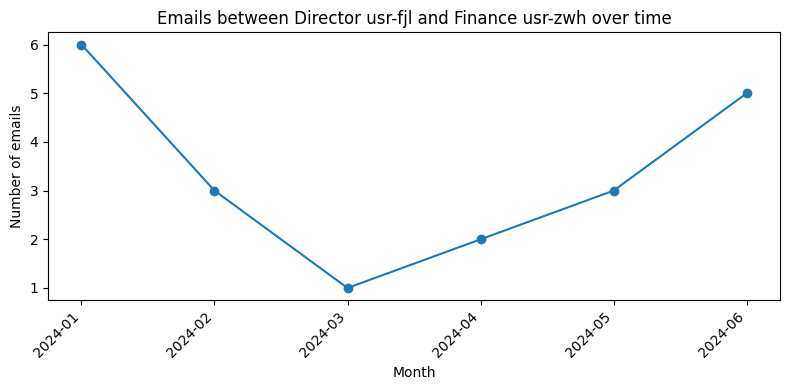

,datetime,sender,recipient,month
13573,2024-01-04 15:00:04.005513,usr-fjl@codecrafters-inc.com,usr-zwh@codecrafters-inc.com,2024-01
22724,2024-01-07 10:06:27.405544,usr-fjl@codecrafters-inc.com,usr-zwh@codecrafters-inc.com,2024-01
57540,2024-01-16 14:53:16.097806,usr-fjl@codecrafters-inc.com,usr-zwh@codecrafters-inc.com,2024-01
65622,2024-01-18 19:29:46.854669,usr-fjl@codecrafters-inc.com,usr-zwh@codecrafters-inc.com,2024-01
72047,2024-01-20 14:32:00.736767,usr-fjl@codecrafters-inc.com,usr-zwh@codecrafters-inc.com,2024-01


In [50]:
suspect_email = 'usr-fjl@codecrafters-inc.com'
finance_email = 'usr-zwh@codecrafters-inc.com'

email_data['month'] = email_data['datetime'].dt.to_period('M')

pair_mask = (
    ((email_data['sender'] == suspect_email) & (email_data['recipient'] == finance_email)) |
    ((email_data['sender'] == finance_email) & (email_data['recipient'] == suspect_email))
)

pair_emails = email_data[pair_mask]

emails_per_month = (
    pair_emails
    .groupby('month')
    .size()
    .rename('emails_between')
    .reset_index()
)

plt.figure(figsize=(8, 4))
plt.plot(emails_per_month['month'].astype(str), emails_per_month['emails_between'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of emails')
plt.xlabel('Month')
plt.title('Emails between Director usr-fjl and Finance usr-zwh over time')
plt.tight_layout()
plt.show()

pair_emails.head()


### Question 7: Describe what you believe are the key findings of your investigation. You should clearly state the suspect identified, and the sequential order of suspicious events, including the date and time that these occurred. You should then provide your own critical reflection of what has occurred in this scenario, giving justification for any assumptions made. Limit your response to a maximum of 400 words. 

Please make clear which dataset you have used for your investigation.

#### (10 marks)

### Key Findings and Critical Reflection

Across the six datasets used in this investigation (`employee_data`, `login_data`, `usb_data`, `file_data`, `web_data`, and `email_data`), one user was consistently identified as the primary suspect: **usr-fjl**, a Director assigned to PC `pc52`. The key findings centre around a sequence of anomalous events occurring on **11 April 2024** and **13 April 2024**.

The most significant anomaly was that all **eight USB insert/remove events** attributed to `usr-fjl` occurred on **`pc99`**, which belongs to Finance user **usr-zwh**, rather than on the Director’s own machine. No other employee in the organisation ever used USB devices on a computer they were not assigned to, making this behaviour uniquely suspicious.

**Sequence of events (chronological):**

- **11 April 2024 –  `pc99`**  
  - 13:09–13:38: USB insert/remove while Finance user `usr-zwh` is logged in.  
  - 19:13–19:31: Another USB pair after the Finance user logs off.  

- **13 April 2024 –  `pc99`**  
  - 07:59–08:52: USB activity before Finance logs in.  
  - 12:24–12:28: USB activity during Finance's session.  

Correlating this with `file_data`, `usr-fjl` accessed sensitive HR folders (`/docs/employment`, `/private`, `/private/staffreview`) immediately before and after several of the USB actions. Examples include:  
- **11 April 13:08** – access to `/docs/employment` (one minute before the USB insert).  
- **11 April 19:09** – access to `/docs/employment` (four minutes before the second USB insert).  
- **13 April 06:47** – access to `/private/staffreview` shortly before the morning USB event.

Email records (`email_data`) show ongoing communication between `usr-fjl` and `usr-zwh` since January, suggesting a prior relationship that may explain how the Director gained access to the Finance PC.

### Critical Reflection

Based on the combined evidence, the most plausible interpretation is that **the Director used a Finance machine to copy confidential HR documents onto a USB device**, possibly to avoid detection on their assigned PC. The assumptions made — such as treating cross-PC USB activity as suspicious are justified because no other staff member exhibits this behaviour. A limitation is that USB content cannot be inspected directly, so the conclusion relies on correlated activity rather than absolute proof. However, the alignment of login times, file access, USB actions, and prior communication provides strong evidence of intentional data Extraction.
